# GodelEnv - Training Evidence Notebook

This notebook runs the same free-form JSON training pipeline as `train.py`.
GodelEnv is a recursive self-improvement environment where the agent can either
improve the current answer directly or propose a `StrategyPatch` that mutates
its own reasoning policy.

Pipeline:
1. Collect prompts from the live environment
2. Build a heuristic warm-start dataset
3. Train a tiny local model with SFT
4. Refine with GRPO
5. Export loss, reward, and before/after plots plus a metrics JSON summary

Reproducibility notes:
- The notebook defaults to deterministic grading and strategy evaluation.
- The local model generates complete JSON actions and strategy patches.
- For the stronger hybrid path, switch the modes below from `deterministic` to `auto`.

In [ ]:
from pathlib import Path
import json
import os
import subprocess
import sys

from dotenv import load_dotenv
import torch


load_dotenv(override=False)
os.environ.setdefault("WANDB_DISABLED", "true")
os.environ.setdefault("WANDB_MODE", "disabled")
os.environ.setdefault("TRL_EXPERIMENTAL_SILENCE", "1")


def _in_colab() -> bool:
    return "COLAB_RELEASE_TAG" in os.environ


if _in_colab() and not (Path.cwd() / "pyproject.toml").exists():
    repo_dir = Path("/content/GodelEnv")
    if not repo_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/dwan-ith/GodelEnv.git", str(repo_dir)],
            check=True,
        )
    os.chdir(repo_dir)

if _in_colab():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", ".[train]"],
        check=True,
    )

from godel_engine.rollout import collect_local_prompt_dataset
from godel_engine.training_support import (
    build_supervised_examples,
    build_freeform_model,
    evaluate_model,
    load_tokenizer,
    plot_before_after,
    plot_training_curves,
    run_grpo,
    run_sft,
)

## 1. Configure the Run

In [3]:
TASKS = ["factual_qa", "alignment_qa", "reasoning", "strategy_optimization"]
NUM_PROMPTS = 16
SFT_STEPS = 20
GRPO_STEPS = 10
MAX_INPUT_LENGTH = 512
MAX_NEW_TOKENS = 192
EFFECTIVE_MAX_NEW_TOKENS = max(MAX_NEW_TOKENS, 160)
OUTPUT_DIR = Path("artifacts/training_run")
GRADING_MODE = os.getenv("GODEL_GRADING_MODE", "deterministic")
STRATEGY_EVAL_MODE = os.getenv("GODEL_STRATEGY_EVAL_MODE", "deterministic")
USE_CPU = not torch.cuda.is_available()
os.environ["GODEL_GRADING_MODE"] = GRADING_MODE
os.environ["GODEL_STRATEGY_EVAL_MODE"] = STRATEGY_EVAL_MODE
print(f"Training config: {NUM_PROMPTS} prompts, {SFT_STEPS} SFT steps, {GRPO_STEPS} GRPO steps")
print(f"Effective completion length for GRPO/eval: {EFFECTIVE_MAX_NEW_TOKENS} tokens")
print(f"Modes: grading={GRADING_MODE}, strategy_eval={STRATEGY_EVAL_MODE}")
print(f"CUDA available: {torch.cuda.is_available()} | using_cpu={USE_CPU}")

Training config: 16 prompts, 20 SFT steps, 10 GRPO steps
Effective completion length for GRPO/eval: 192 tokens
Modes: grading=deterministic, strategy_eval=deterministic
CUDA available: True | using_cpu=False


## 2. Collect Prompts and Build the Warm-Start Dataset

In [5]:
prompt_data = collect_local_prompt_dataset(
    num_prompts=NUM_PROMPTS,
    tasks=TASKS,
    seed=42,
)
supervised_examples = build_supervised_examples(prompt_data)

print(f"Collected {len(prompt_data)} prompts across {len(TASKS)} task families")
for task in TASKS:
    count = sum(1 for prompt in prompt_data if prompt["task_type"] == task)
    print(f"  {task}: {count} prompts")

Collected 16 prompts across 4 task families
  factual_qa: 4 prompts
  alignment_qa: 4 prompts
  reasoning: 4 prompts
  strategy_optimization: 4 prompts


## 3. Build the Local Model

We use the same free-form JSON model family as the script path.
For larger-scale training, replace this with Unsloth plus a stronger instruct model.

In [7]:
tokenizer = load_tokenizer()
model = build_freeform_model(
    tokenizer,
    max_length=max(MAX_INPUT_LENGTH + EFFECTIVE_MAX_NEW_TOKENS + 64, 1024),
)
total_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Model: GPT-2 freeform ({total_params:,} parameters)")

Model: GPT-2 freeform (30,339,456 parameters)


## 4. Baseline Evaluation (Before Training)

In [9]:
baseline_metrics = evaluate_model(
    model,
    tokenizer,
    prompt_data,
    max_new_tokens=EFFECTIVE_MAX_NEW_TOKENS,
    max_input_length=MAX_INPUT_LENGTH,
    policy_mode="model",
    seed=42,
)
print(
    f"Baseline: mean_reward={baseline_metrics['mean_reward']:.4f}, "
    f"mean_score={baseline_metrics['mean_score']:.4f}"
)
print(
    "Structured policy: "
    f"structured_action_rate={baseline_metrics.get('structured_action_rate', 0.0):.2%}, "
    "Patch behavior: "
    f"proposal_rate={baseline_metrics.get('strategy_patch_rate', 0.0):.2%}, "
    f"acceptance_rate={baseline_metrics.get('patch_acceptance_rate', 0.0):.2%}, "
    f"mean_patch_delta={baseline_metrics.get('mean_patch_improvement', 0.0):+.4f}"
)
for episode in baseline_metrics["episodes"][:4]:
    print(
        f"  {episode['task_type']:25s} "
        f"score={episode['score']:.3f}  reward={episode['reward']:+.3f}"
    )

Baseline: mean_reward=-0.4051, mean_score=0.1865
Structured policy: structured_action_rate=0.00%, Patch behavior: proposal_rate=0.00%, acceptance_rate=0.00%, mean_patch_delta=+0.0000


## 5. Warm-Start with Supervised Traces (SFT)

The warm start teaches the model the JSON action schema and grounded teacher traces.

In [11]:
sft_logs = run_sft(
    model,
    tokenizer,
    supervised_examples,
    output_dir=OUTPUT_DIR / "sft",
    max_steps=SFT_STEPS,
    batch_size=1,
    max_length=MAX_INPUT_LENGTH + EFFECTIVE_MAX_NEW_TOKENS,
    use_cpu=USE_CPU,
)
sft_loss_entries = [item for item in sft_logs if "loss" in item]
print(f"SFT complete: {len(sft_loss_entries)} steps logged")
if sft_loss_entries:
    print(f"  Initial loss: {sft_loss_entries[0]['loss']:.4f}")
    print(f"  Final loss:   {sft_loss_entries[-1]['loss']:.4f}")

SFT complete: 20 steps logged
  Initial loss: 10.9007
  Final loss:   9.5247


## 6. Refine with Group Relative Policy Optimization (GRPO)

GRPO uses the environment reward directly over generated JSON actions and
strategy patches.

In [13]:
grpo_logs = run_grpo(
    model,
    tokenizer,
    prompt_data,
    output_dir=OUTPUT_DIR / "grpo",
    max_steps=GRPO_STEPS,
    batch_size=2,
    num_generations=2,
    max_completion_length=EFFECTIVE_MAX_NEW_TOKENS,
    max_new_tokens=EFFECTIVE_MAX_NEW_TOKENS,
    use_cpu=USE_CPU,
)
grpo_reward_entries = [item for item in grpo_logs if "reward" in item]
print(f"GRPO complete: {len(grpo_reward_entries)} steps logged")
if grpo_reward_entries:
    print(f"  Initial reward: {grpo_reward_entries[0]['reward']:.4f}")
    print(f"  Final reward:   {grpo_reward_entries[-1]['reward']:.4f}")

GRPO complete: 10 steps logged
  Initial reward: -0.4388
  Final reward:   -0.8021


## 7. Evaluate the Trained Model

In [15]:
trained_metrics = evaluate_model(
    model,
    tokenizer,
    prompt_data,
    max_new_tokens=EFFECTIVE_MAX_NEW_TOKENS,
    max_input_length=MAX_INPUT_LENGTH,
    policy_mode="model",
    seed=42,
)
print(
    f"Trained: mean_reward={trained_metrics['mean_reward']:.4f}, "
    f"mean_score={trained_metrics['mean_score']:.4f}"
)
print("\nImprovement:")
print(
    f"  Reward: {baseline_metrics['mean_reward']:.4f} -> {trained_metrics['mean_reward']:.4f} "
    f"(delta={trained_metrics['mean_reward'] - baseline_metrics['mean_reward']:+.4f})"
)
print(
    f"  Score:  {baseline_metrics['mean_score']:.4f} -> {trained_metrics['mean_score']:.4f} "
    f"(delta={trained_metrics['mean_score'] - baseline_metrics['mean_score']:+.4f})"
)
print(
    "  Structured action rate: "
    f"{baseline_metrics.get('structured_action_rate', 0.0):.2%} -> "
    f"{trained_metrics.get('structured_action_rate', 0.0):.2%}"
)
print(
    "  Patch proposal rate: "
    f"{baseline_metrics.get('strategy_patch_rate', 0.0):.2%} -> "
    f"{trained_metrics.get('strategy_patch_rate', 0.0):.2%}"
)
print(
    "  Patch acceptance rate: "
    f"{baseline_metrics.get('patch_acceptance_rate', 0.0):.2%} -> "
    f"{trained_metrics.get('patch_acceptance_rate', 0.0):.2%}"
)
print(
    "  Mean patch delta: "
    f"{baseline_metrics.get('mean_patch_improvement', 0.0):+.4f} -> "
    f"{trained_metrics.get('mean_patch_improvement', 0.0):+.4f}"
)

Trained: mean_reward=-0.3656, mean_score=0.1882

Improvement:
  Reward: -0.4051 -> -0.3656 (delta=+0.0395)
  Score:  0.1865 -> 0.1882 (delta=+0.0017)
  Structured action rate: 0.00% -> 0.00%
  Patch proposal rate: 0.00% -> 0.00%
  Patch acceptance rate: 0.00% -> 0.00%
  Mean patch delta: +0.0000 -> +0.0000


## 8. Save Plots and Model Artifacts

In [17]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plots = plot_training_curves(sft_logs, grpo_logs, OUTPUT_DIR)
before_after_path = plot_before_after(baseline_metrics, trained_metrics, OUTPUT_DIR)

model_dir = OUTPUT_DIR / "final_model"
model_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)

summary = {
    "tasks": TASKS,
    "prompt_count": len(prompt_data),
    "sft_steps": SFT_STEPS,
    "grpo_steps": GRPO_STEPS,
    "baseline": baseline_metrics,
    "trained": trained_metrics,
    "improvement": {
        "reward_delta": trained_metrics["mean_reward"] - baseline_metrics["mean_reward"],
        "score_delta": trained_metrics["mean_score"] - baseline_metrics["mean_score"],
        "structured_action_rate_delta": trained_metrics.get("structured_action_rate", 0.0)
        - baseline_metrics.get("structured_action_rate", 0.0),
        "patch_rate_delta": trained_metrics.get("strategy_patch_rate", 0.0)
        - baseline_metrics.get("strategy_patch_rate", 0.0),
        "patch_acceptance_delta": trained_metrics.get("patch_acceptance_rate", 0.0)
        - baseline_metrics.get("patch_acceptance_rate", 0.0),
        "mean_patch_improvement_delta": trained_metrics.get("mean_patch_improvement", 0.0)
        - baseline_metrics.get("mean_patch_improvement", 0.0),
    },
    "artifacts": {
        "loss_curve": str(plots["loss_curve"]),
        "reward_curve": str(plots["reward_curve"]),
        "before_after": str(before_after_path),
        "model_dir": str(model_dir),
    },
}
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
try:
    import wandb

    wandb.finish(quiet=True)
except Exception:
    pass
print("Artifacts saved:")
for name, path in summary["artifacts"].items():
    print(f"  {name}: {path}")

Artifacts saved:
  loss_curve: artifacts\training_run\loss_curve.png
  reward_curve: artifacts\training_run\reward_curve.png
  before_after: artifacts\training_run\before_after.png
  model_dir: artifacts\training_run\final_model


## 9. Training Evidence - Inline Plots

=== SFT Loss Curve ===


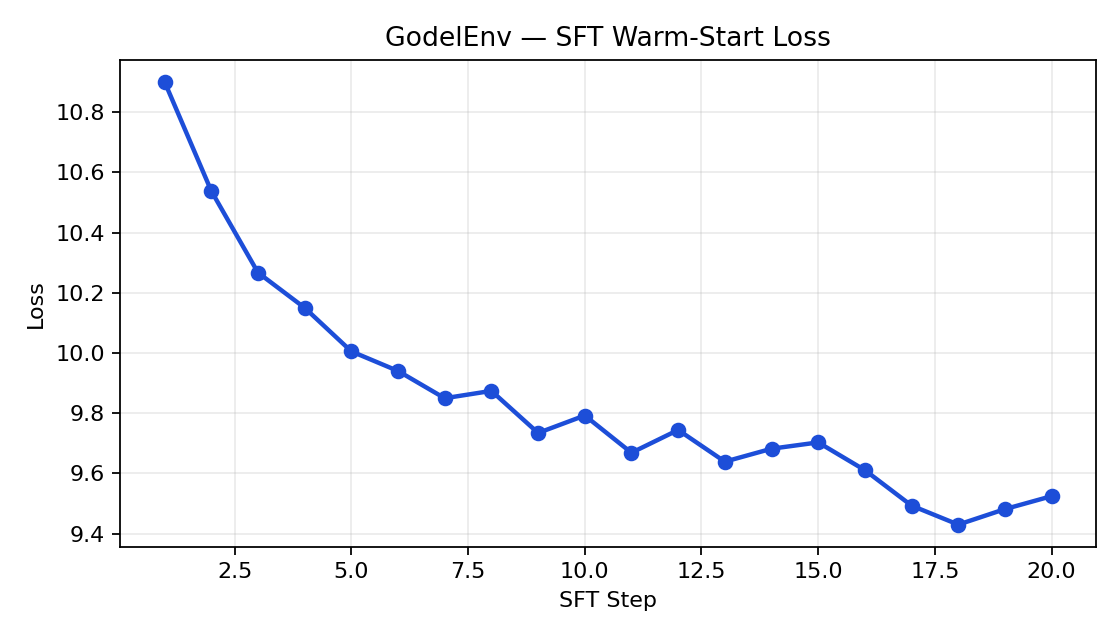


=== GRPO Reward Curve ===


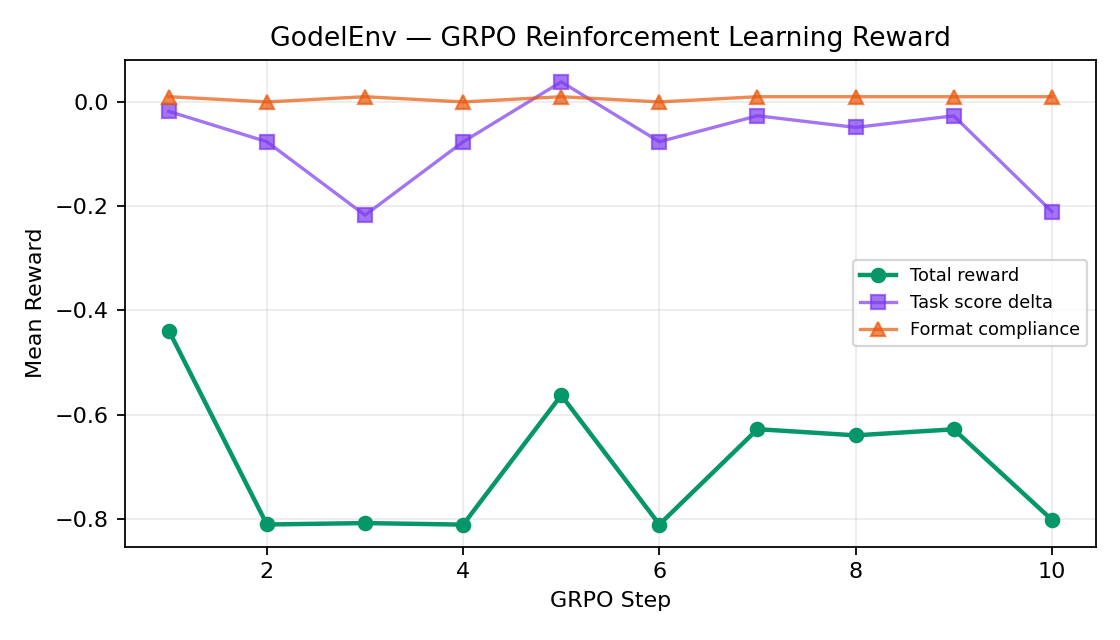


=== Before / After Training ===


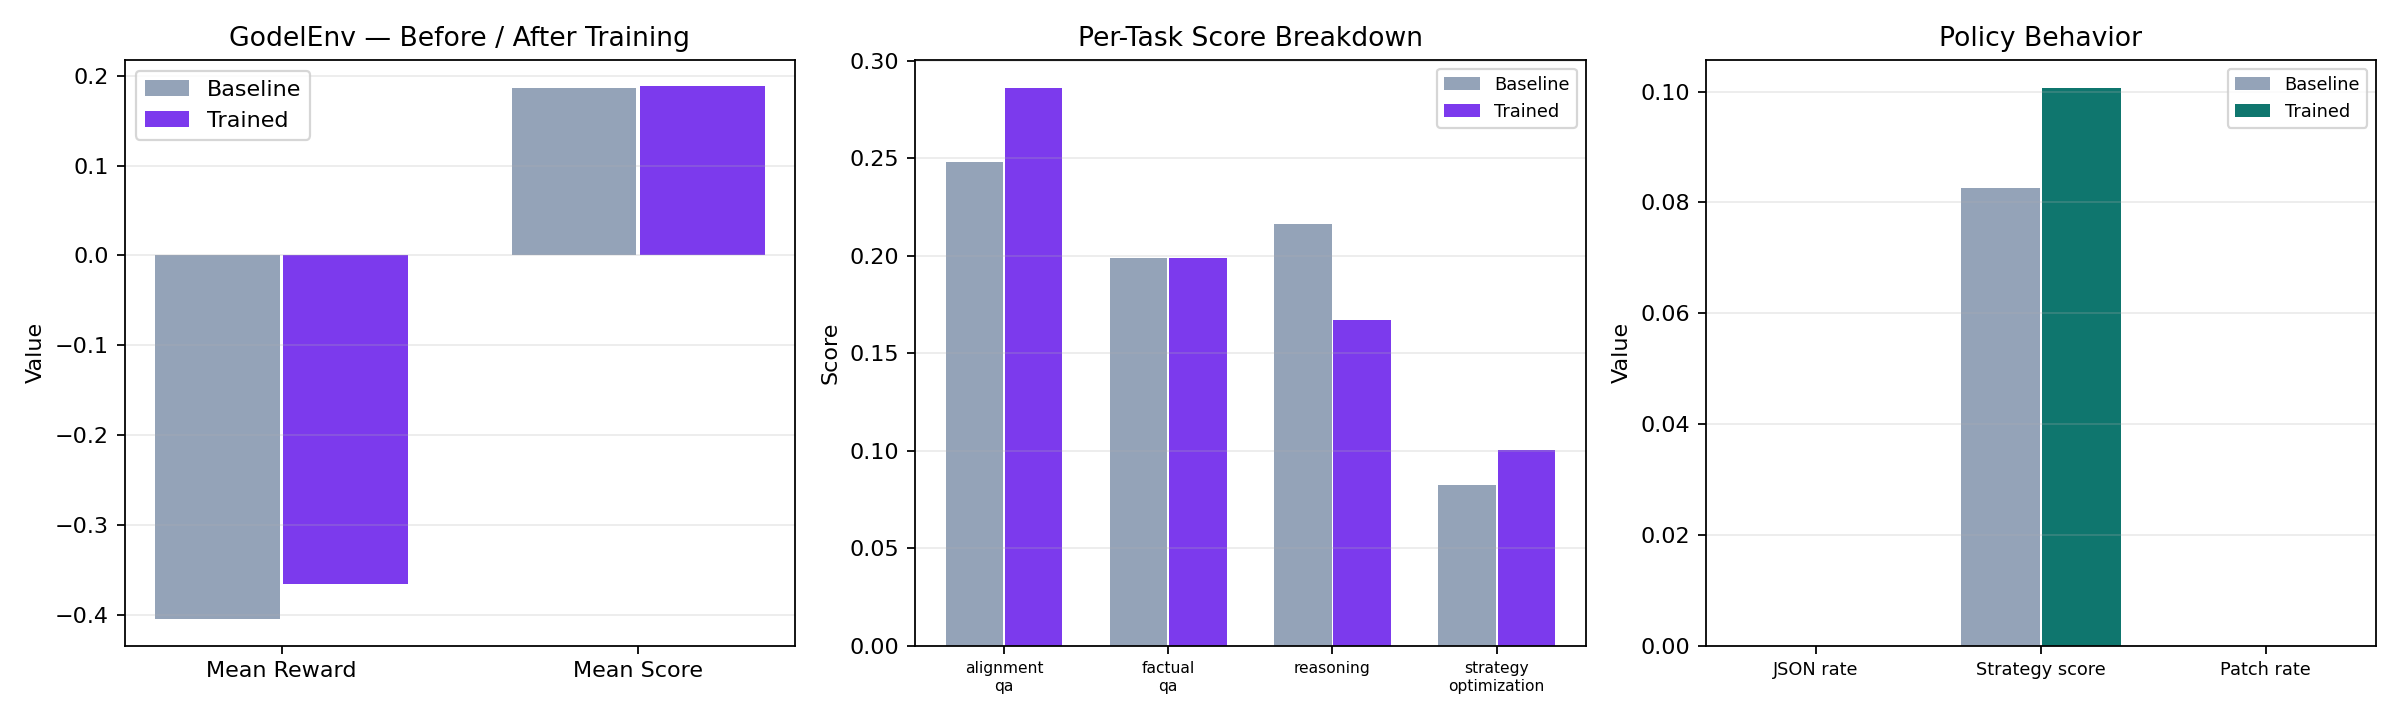

In [19]:
from IPython.display import Image, display

print("=== SFT Loss Curve ===")
display(Image(filename=str(plots["loss_curve"])))
print("\n=== GRPO Reward Curve ===")
display(Image(filename=str(plots["reward_curve"])))
print("\n=== Before / After Training ===")
display(Image(filename=str(before_after_path)))